In [48]:
# required libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# csv file load
df = pd.read_csv("Zepto_Sales & Inventory.csv")

In [50]:
# Data understanding(EDA Start)
df.shape    # Rows & colimns count
df.columns  # column names
df.info()   # Data types
df.describe() # Statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3730 entries, 0 to 3729
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Category                  3730 non-null   object
 1   Name                      3730 non-null   object
 2   MRP                       3730 non-null   int64 
 3   Discount Percent          3730 non-null   int64 
 4   Available Quantity        3730 non-null   int64 
 5   Discounted Selling Price  3730 non-null   int64 
 6   Weight In Gms             3730 non-null   int64 
 7   Out Of Stock              3730 non-null   bool  
 8   Quantity                  3730 non-null   int64 
dtypes: bool(1), int64(6), object(2)
memory usage: 236.9+ KB


,MRP,Discount Percent,Available Quantity,Discounted Selling Price,Weight In Gms,Quantity
count,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000
mean,15680.482574,7.615818,4.007507,14193.206434,387.917694,213.251206
std,16093.113838,9.214038,2.203619,13854.430798,678.270812,194.781332
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6000.000000,0.000000,2.000000,5500.000000,100.000000,50.000000
50%,11000.000000,6.000000,5.000000,10400.000000,225.000000,181.000000
75%,20000.000000,10.000000,6.000000,18400.000000,450.000000,340.000000
max,260000.000000,51.000000,6.000000,139900.000000,10000.000000,1500.000000


In [51]:
# Data Cleaning -step 4
# missing Values check
df.isnull().sum()
# Duplicates remove
df.drop_duplicates(inplace=True)

In [52]:
df.columns

Index(['Category', 'Name', 'MRP', 'Discount Percent', 'Available Quantity',
       'Discounted Selling Price', 'Weight In Gms', 'Out Of Stock',
       'Quantity'],
      dtype='object')

In [53]:
# revenue column create 
#  Revenue = Discounted Selling Price * Quantity
df["Revenue"] = df["Discounted Selling Price"] * df["Quantity"]

In [54]:
print = df.columns

In [55]:
del print

In [56]:
# Total revenue
total_revenue = df["Revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 12220682800


In [57]:
# Analysis 1 category wise revenue
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
print(category_revenue)


Category
Chocolates & Candies     1734991700
Ice Cream & Desserts     1734991700
Packaged Food            1734991700
Munchies                 1361622600
Cooking Essentials       1361622600
Paan Corner              1258107500
Personal Care            1258107500
Meats, Fish & Eggs        369397600
Home & Cleaning           367834300
Dairy, Bread & Batter     333048300
Beverages                 333048300
Biscuits                  179207600
Health & Hygiene          149611700
Fruits & Vegetables        44099700
Name: Revenue, dtype: int64


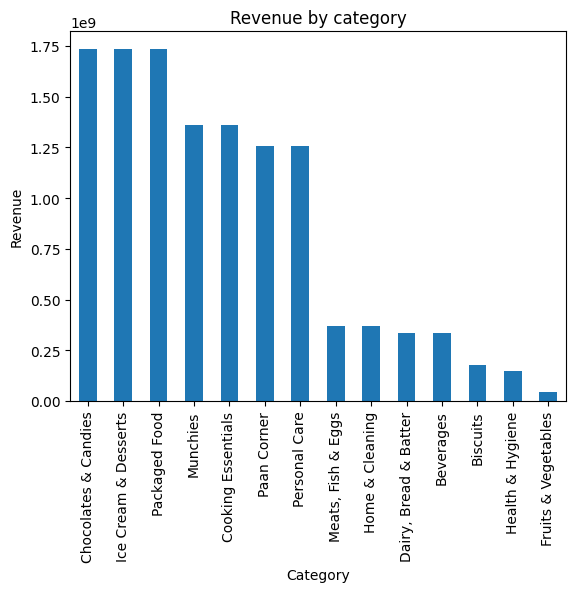

In [58]:
category_revenue.plot(kind="bar") # chart
plt.title("Revenue by category")
plt.ylabel("Revenue")
plt.show()

In [64]:
del print

In [65]:
# Analysis 2 Top selling price
top_products = df.groupby("Name")["Quantity"].sum().sort_values(ascending=False).head(10)
print(top_products)

Name
Kellogg's Original Corn Flakes                                               4050
MTR Roasted Vermicelli                                                       3750
Pedigree Puppy Dry Dog Food Food Chicken & Milk                              3609
Kellogg's Special K Original Corn Flakes                                     3570
Ching's Secret Green Chilli Sauce                                            3315
Whiskas Kitten (2-12 months) Dry Cat Food Food Ocean Fish                    3300
Amul Delicious Fat Spread - Cholesterol Free                                 3000
Savlon Moisture Shield Germ Protection Handwash Refill (Buy 1 Get 1 Free)    3000
Mother's Recipe Pickle - Mango                                               3000
Godrej Yummiez Chicken Nuggets                                               3000
Name: Quantity, dtype: int64


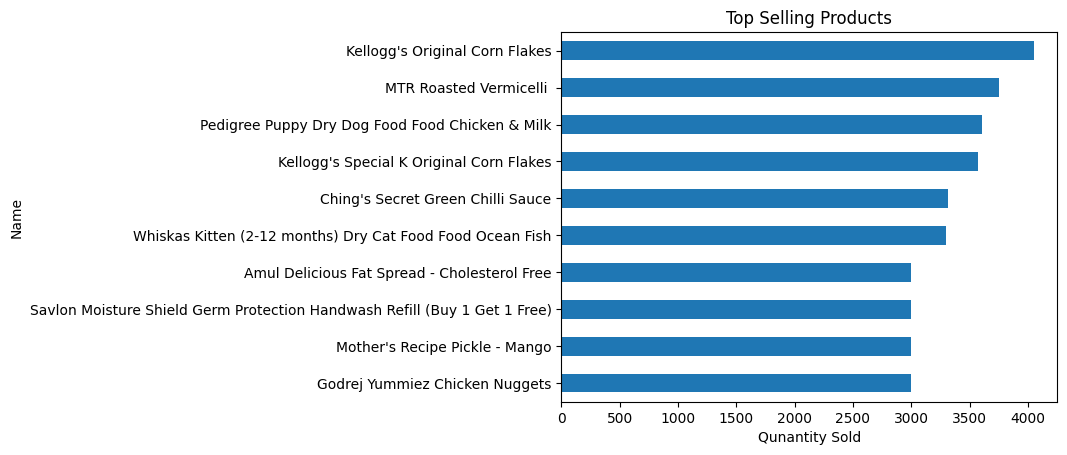

In [ ]:
# chart
top_products.plot(kind="barh")
plt.title("Top Selling Products")
plt.xlabel("Qunantity Sold")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Analysis 3 Average discount by category
avg_discount = df.groupby("Category")["Discount Percent"].mean()
print(avg_discount)

Category
Beverages                 7.155039
Biscuits                  8.244898
Chocolates & Candies      8.324742
Cooking Essentials        7.163424
Dairy, Bread & Batter     7.155039
Fruits & Vegetables      15.462366
Health & Hygiene          8.051546
Home & Cleaning           5.675258
Ice Cream & Desserts      8.324742
Meats, Fish & Eggs       11.031746
Munchies                  7.163424
Paan Corner               6.239067
Packaged Food             8.324742
Personal Care             6.239067
Name: Discount Percent, dtype: float64


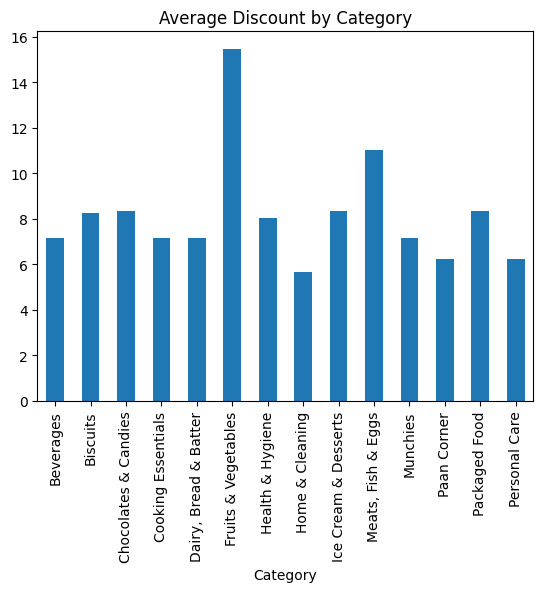

In [ ]:
# chart
avg_discount.plot(kind="bar")
plt.title("Average Discount by Category")
plt.show()

In [ ]:
# Analysis 4 Stock Availability
stock = df.groupby("Category")["Available Quantity"].sum()
print(stock)



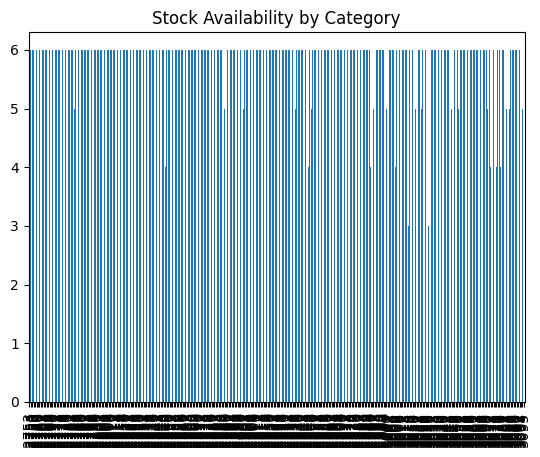

In [ ]:
stock.plot(kind="bar")
plt.title("Stock Availability by Category")
plt.show()

In [ ]:
# Analysis 5 Out of stock count
out_stock = df.groupby("Category") ["Out Of Stock"].sum()
print(out_stock)

Category
Beverages                28
Biscuits                 42
Chocolates & Candies     45
Cooking Essentials       64
Dairy, Bread & Batter    28
Fruits & Vegetables       6
Health & Hygiene         13
Home & Cleaning          19
Ice Cream & Desserts     45
Meats, Fish & Eggs       12
Munchies                 64
Paan Corner              21
Packaged Food            45
Personal Care            21
Name: Out Of Stock, dtype: int64


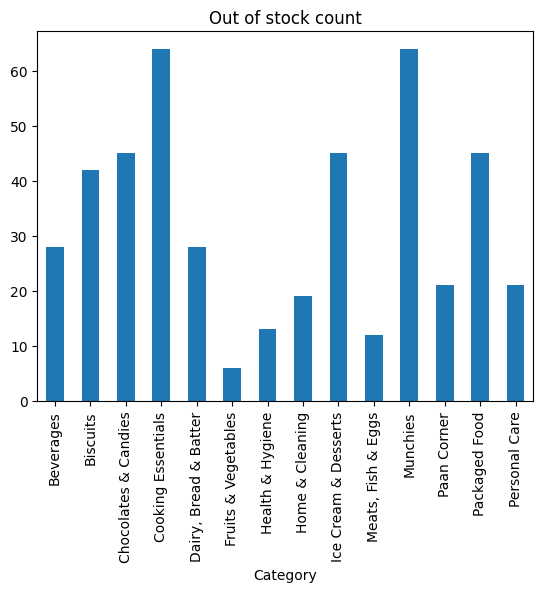

In [ ]:
out_stock.plot(kind="bar")
plt.title("Out of stock count")
plt.show()

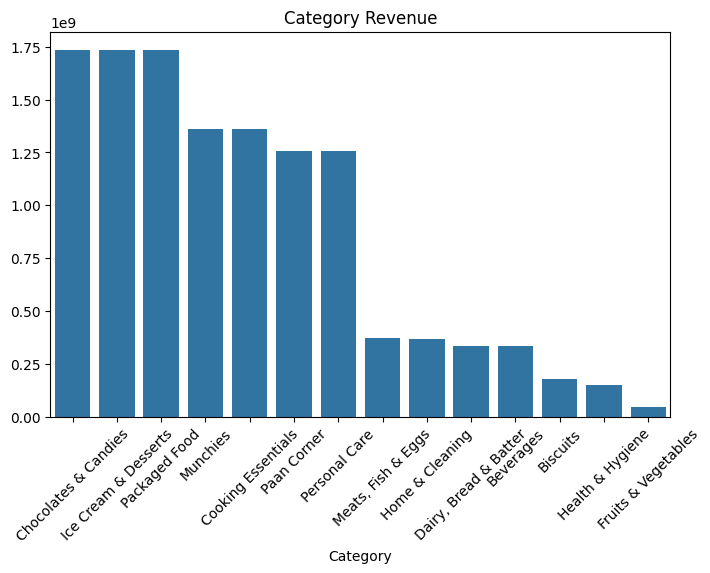

In [69]:
# Advanced Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=category_revenue.index, y=category_revenue.values)
plt.xticks(rotation=45)
plt.title("Category Revenue")
plt.show()

In [70]:
# BUsiness insights
print("Highest revenue category:",category_revenue.idxmax())
print("Top Selling Product:",top_products.idxmax())
print("Highest discount category:",avg_discount.idxmax())

Highest revenue category: Chocolates & Candies
Top Selling Product: Kellogg's Original Corn Flakes
Highest discount category: Fruits & Vegetables


In [71]:
# save cleaned dataset
df.to_csv("Zepto_Sales &Inventory",index=False)